# Task 1: Simple Vectorized MLP (Neural Network) from Scratch

A beginner-friendly 2-layer Neural Network written in simple NumPy lines without complex classes.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)

### 1. Create Simple Toy Dataset

In [2]:
# 100 data points with 2 input features
X = np.random.randn(100, 2)
y = (X[:, 0] + X[:, 1] > 0).astype(int)  # 0 or 1 binary target
Y = y.reshape(-1, 1)

### 2. Initialize Weights & Biases

In [3]:
# Input(2) -> Hidden(4) -> Output(1)
W1 = np.random.randn(2, 4) * 0.1
b1 = np.zeros((1, 4))
W2 = np.random.randn(4, 1) * 0.1
b2 = np.zeros((1, 1))

### 3. Linear Forward Pass, Loss, and Backpropagation Loop

In [4]:
lr = 0.1
losses = []

for epoch in range(200):
    # --- FORWARD PASS ---
    z1 = np.dot(X, W1) + b1
    a1 = np.maximum(0, z1)              # ReLU activation
    z2 = np.dot(a1, W2) + b2
    pred = 1 / (1 + np.exp(-z2))         # Sigmoid activation

    # --- LOSS (Binary Cross-Entropy) ---
    loss = -np.mean(Y * np.log(pred + 1e-7) + (1 - Y) * np.log(1 - pred + 1e-7))
    losses.append(loss)

    # --- BACKWARD PASS (Gradients) ---
    dz2 = pred - Y
    dW2 = np.dot(a1.T, dz2) / 100
    db2 = np.sum(dz2, axis=0, keepdims=True) / 100

    da1 = np.dot(dz2, W2.T)
    dz1 = da1 * (z1 > 0)                # Derivative of ReLU
    dW1 = np.dot(X.T, dz1) / 100
    db1 = np.sum(dz1, axis=0, keepdims=True) / 100

    # --- UPDATE WEIGHTS ---
    W1 -= lr * dW1
    b1 -= lr * db1
    W2 -= lr * dW2
    b2 -= lr * db2

print(f'Final Loss after 200 epochs: {losses[-1]:.4f}')

Final Loss after 200 epochs: 0.2096


### 4. Plot Loss Curve

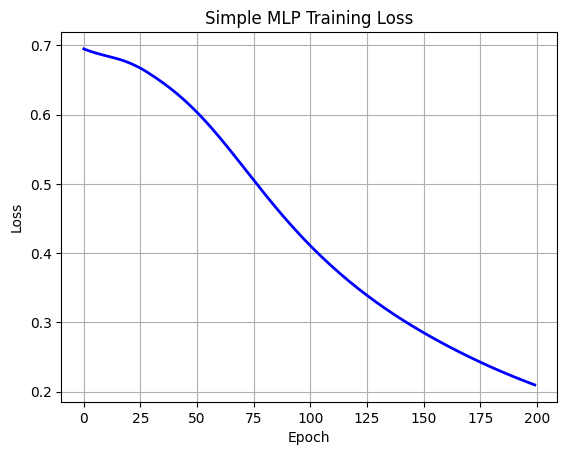

In [5]:
plt.plot(losses, color='blue', lw=2)
plt.title('Simple MLP Training Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.grid(True)
plt.show()